##### 📊 Stock & Bitcoin Price Analysis Using Python

This project performs Exploratory Data Analysis (EDA) on Stock and Bitcoin market data using Python. It includes return analysis, volatility, technical indicators, correlation analysis, and statistical tests.

In [5]:
import yfinance as yf
import numpy as np
import pandas as pd

##### 1. Data Collection

In [6]:
# Downloading historical data of "RS" from 1-11-2024 to 31-10-2025
RS_Data = yf.download("RS", start = "2024-11-1", end = "2025-10-31", auto_adjust = True)
RS_Data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RS,RS,RS,RS,RS
Date,,,,,
2024-11-01,279.190765,280.464719,275.991281,278.723962,235700
2024-11-04,281.087128,282.030440,277.712603,278.383620,219200
2024-11-05,283.673950,284.024031,277.741784,278.811524,294300
2024-11-06,317.341400,317.876255,306.196698,309.279489,698100
2024-11-07,312.196930,317.039917,306.332845,316.699541,565000
...,...,...,...,...,...
2025-10-24,273.833496,276.679243,268.744762,268.744762,420200
2025-10-27,275.414520,277.687150,268.912772,273.181393,305600


In [7]:
RS_Data.columns = RS_Data.columns.get_level_values(0)
RS_Data.columns


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [8]:
RS_Data

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-11-01,279.190765,280.464719,275.991281,278.723962,235700
2024-11-04,281.087128,282.030440,277.712603,278.383620,219200
2024-11-05,283.673950,284.024031,277.741784,278.811524,294300
2024-11-06,317.341400,317.876255,306.196698,309.279489,698100
2024-11-07,312.196930,317.039917,306.332845,316.699541,565000
...,...,...,...,...,...
2025-10-24,273.833496,276.679243,268.744762,268.744762,420200
2025-10-27,275.414520,277.687150,268.912772,273.181393,305600
2025-10-28,276.837372,279.949896,274.544961,275.542927,547800


In [9]:
RS_Data.reset_index(inplace=True)

RS_Data['Date'] = pd.to_datetime(RS_Data['Date']) # To set in standard date & time format.
RS_Data = RS_Data.set_index('Date')
RS_Data  

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-11-01,279.190765,280.464719,275.991281,278.723962,235700
2024-11-04,281.087128,282.030440,277.712603,278.383620,219200
2024-11-05,283.673950,284.024031,277.741784,278.811524,294300
2024-11-06,317.341400,317.876255,306.196698,309.279489,698100
2024-11-07,312.196930,317.039917,306.332845,316.699541,565000
...,...,...,...,...,...
2025-10-24,273.833496,276.679243,268.744762,268.744762,420200
2025-10-27,275.414520,277.687150,268.912772,273.181393,305600
2025-10-28,276.837372,279.949896,274.544961,275.542927,547800


##### 2. Data Cleaning

In [10]:
# Full daily Date Range
# Fill missing dates and handle missing values using interpolation.
# Ensure index is proper datetime type


# Create full date range from min to max date
Full_Date_Range = pd.date_range(start=RS_Data.index.min(), end=RS_Data.index.max())

# Reindex the dataframe using the full date range
RS_Data = RS_Data.reindex(Full_Date_Range)

# Rename the index back to 'Date' for clarity
RS_Data.index.name = 'Date'

# View clean result
print(RS_Data.head())

Price            Close        High         Low        Open    Volume
Date                                                                
2024-11-01  279.190765  280.464719  275.991281  278.723962  235700.0
2024-11-02         NaN         NaN         NaN         NaN       NaN
2024-11-03         NaN         NaN         NaN         NaN       NaN
2024-11-04  281.087128  282.030440  277.712603  278.383620  219200.0
2024-11-05  283.673950  284.024031  277.741784  278.811524  294300.0


In [11]:
# Reset index 

RS_Data = RS_Data.reset_index()

# Uplift 'Date' column
cols = ['Date'] + [col for col in RS_Data if col!= 'Date']
RS_Data = RS_Data[cols]

# Result
RS_Data


Price,Date,Close,High,Low,Open,Volume
0,2024-11-01,279.190765,280.464719,275.991281,278.723962,235700.0
1,2024-11-02,NaN,NaN,NaN,NaN,NaN
2,2024-11-03,NaN,NaN,NaN,NaN,NaN
3,2024-11-04,281.087128,282.030440,277.712603,278.383620,219200.0
4,2024-11-05,283.673950,284.024031,277.741784,278.811524,294300.0
...,...,...,...,...,...,...
359,2025-10-26,NaN,NaN,NaN,NaN,NaN
360,2025-10-27,275.414520,277.687150,268.912772,273.181393,305600.0
361,2025-10-28,276.837372,279.949896,274.544961,275.542927,547800.0
362,2025-10-29,278.872864,281.224528,273.122086,275.740558,458100.0


##### Handling Missing Values

In [12]:
# Ensure column header print left aligned
pd.set_option('display.colheader_justify','left')

# Print entire DataFrame including index, left aligned
print(RS_Data.to_string(justify='left'))

Price Date        Close       High        Low         Open        Volume   
0     2024-11-01  279.190765  280.464719  275.991281  278.723962   235700.0
1     2024-11-02         NaN         NaN         NaN         NaN        NaN
2     2024-11-03         NaN         NaN         NaN         NaN        NaN
3     2024-11-04  281.087128  282.030440  277.712603  278.383620   219200.0
4     2024-11-05  283.673950  284.024031  277.741784  278.811524   294300.0
5     2024-11-06  317.341400  317.876255  306.196698  309.279489   698100.0
6     2024-11-07  312.196930  317.039917  306.332845  316.699541   565000.0
7     2024-11-08  311.798187  313.373608  308.044409  308.812651   287500.0
8     2024-11-09         NaN         NaN         NaN         NaN        NaN
9     2024-11-10         NaN         NaN         NaN         NaN        NaN
10    2024-11-11  314.287720  315.892314  309.960179  313.723691   334900.0
11    2024-11-12  311.010498  312.955469  307.626239  312.041330   402800.0
12    2024-1

In [13]:
# Handling NaN values

RS_Data = RS_Data.interpolate(method = 'linear')  # interpolate(): This is a pandas method used to estimate and fill missing values based on existing data points.
RS_Data

Price,Date,Close,High,Low,Open,Volume
0,2024-11-01,279.190765,280.464719,275.991281,278.723962,235700.0
1,2024-11-02,279.822886,280.986626,276.565055,278.610515,230200.0
2,2024-11-03,280.455007,281.508533,277.138829,278.497067,224700.0
3,2024-11-04,281.087128,282.030440,277.712603,278.383620,219200.0
4,2024-11-05,283.673950,284.024031,277.741784,278.811524,294300.0
...,...,...,...,...,...,...
359,2025-10-26,274.887512,277.351181,268.856769,271.702516,343800.0
360,2025-10-27,275.414520,277.687150,268.912772,273.181393,305600.0
361,2025-10-28,276.837372,279.949896,274.544961,275.542927,547800.0
362,2025-10-29,278.872864,281.224528,273.122086,275.740558,458100.0


In [14]:
# Missing Counts

missing_counts = RS_Data.isna().sum().sum()
print(f"Total number of missing counts:{missing_counts}")

Total number of missing counts:0


##### 3. Daily Returns Analysis

In [15]:
# Create daily return feature
# It gives first value as NaN as there was no previous value

RS_Data['Daily Return'] = RS_Data['Close'].pct_change()
RS_Data

Price,Date,Close,High,Low,Open,Volume,Daily Return
0,2024-11-01,279.190765,280.464719,275.991281,278.723962,235700.0,NaN
1,2024-11-02,279.822886,280.986626,276.565055,278.610515,230200.0,0.002264
2,2024-11-03,280.455007,281.508533,277.138829,278.497067,224700.0,0.002259
3,2024-11-04,281.087128,282.030440,277.712603,278.383620,219200.0,0.002254
4,2024-11-05,283.673950,284.024031,277.741784,278.811524,294300.0,0.009203
...,...,...,...,...,...,...,...
359,2025-10-26,274.887512,277.351181,268.856769,271.702516,343800.0,0.001921
360,2025-10-27,275.414520,277.687150,268.912772,273.181393,305600.0,0.001917
361,2025-10-28,276.837372,279.949896,274.544961,275.542927,547800.0,0.005166
362,2025-10-29,278.872864,281.224528,273.122086,275.740558,458100.0,0.007353


In [16]:
# Makes returns additive over time (good for compounding).
# Handles large percentage moves more accurately.
# Keeps data more normally distributed → better for statistical & quant models.

RS_Data['Log Normal'] = np.log(RS_Data['Close']/RS_Data['Close'].shift(1))
RS_Data

Price,Date,Close,High,Low,Open,Volume,Daily Return,Log Normal
0,2024-11-01,279.190765,280.464719,275.991281,278.723962,235700.0,NaN,NaN
1,2024-11-02,279.822886,280.986626,276.565055,278.610515,230200.0,0.002264,0.002262
2,2024-11-03,280.455007,281.508533,277.138829,278.497067,224700.0,0.002259,0.002256
3,2024-11-04,281.087128,282.030440,277.712603,278.383620,219200.0,0.002254,0.002251
4,2024-11-05,283.673950,284.024031,277.741784,278.811524,294300.0,0.009203,0.009161
...,...,...,...,...,...,...,...,...
359,2025-10-26,274.887512,277.351181,268.856769,271.702516,343800.0,0.001921,0.001919
360,2025-10-27,275.414520,277.687150,268.912772,273.181393,305600.0,0.001917,0.001915
361,2025-10-28,276.837372,279.949896,274.544961,275.542927,547800.0,0.005166,0.005153
362,2025-10-29,278.872864,281.224528,273.122086,275.740558,458100.0,0.007353,0.007326


##### 4. Technical Indicators

In [17]:
# Moving Averages

# Simple Moving Average
RS_Data['SMA_20'] = RS_Data['Close'].rolling(window=20).mean()
RS_Data['SMA_50'] = RS_Data['Close'].rolling(window=50).mean()

# Exponential Moving Average
RS_Data['EMA_20'] = RS_Data['Close'].ewm(span=20).mean()
RS_Data['EMA_50'] = RS_Data['Close'].ewm(span=50).mean()

RS_Data

Price,Date,Close,High,Low,Open,Volume,Daily Return,Log Normal,SMA_20,SMA_50,EMA_20,EMA_50
0,2024-11-01,279.190765,280.464719,275.991281,278.723962,235700.0,NaN,NaN,NaN,NaN,279.190765,279.190765
1,2024-11-02,279.822886,280.986626,276.565055,278.610515,230200.0,0.002264,0.002262,NaN,NaN,279.522629,279.513147
2,2024-11-03,280.455007,281.508533,277.138829,278.497067,224700.0,0.002259,0.002256,NaN,NaN,279.864992,279.839740
3,2024-11-04,281.087128,282.030440,277.712603,278.383620,219200.0,0.002254,0.002251,NaN,NaN,280.217804,280.170542
4,2024-11-05,283.673950,284.024031,277.741784,278.811524,294300.0,0.009203,0.009161,NaN,NaN,281.053816,280.928376
...,...,...,...,...,...,...,...,...,...,...,...,...
359,2025-10-26,274.887512,277.351181,268.856769,271.702516,343800.0,0.001921,0.001919,272.422998,279.024887,273.693546,278.122210
360,2025-10-27,275.414520,277.687150,268.912772,273.181393,305600.0,0.001917,0.001915,272.339011,278.637288,273.857448,278.016026
361,2025-10-28,276.837372,279.949896,274.544961,275.542927,547800.0,0.005166,0.005153,272.285654,278.284534,274.141250,277.969805
362,2025-10-29,278.872864,281.224528,273.122086,275.740558,458100.0,0.007353,0.007326,272.428931,278.070314,274.591880,278.005219


##### 5. Rolling Volatility

In [18]:
# Calculate 20-day rolling volatility

RS_Data['Rolling_Volatility_20'] = RS_Data['Daily Return'].rolling(window=20).std()
print(RS_Data)

Price Date        Close       High        Low         Open        Volume    \
0     2024-11-01  279.190765  280.464719  275.991281  278.723962  235700.0   
1     2024-11-02  279.822886  280.986626  276.565055  278.610515  230200.0   
2     2024-11-03  280.455007  281.508533  277.138829  278.497067  224700.0   
3     2024-11-04  281.087128  282.030440  277.712603  278.383620  219200.0   
4     2024-11-05  283.673950  284.024031  277.741784  278.811524  294300.0   
..           ...         ...         ...         ...         ...       ...   
359   2025-10-26  274.887512  277.351181  268.856769  271.702516  343800.0   
360   2025-10-27  275.414520  277.687150  268.912772  273.181393  305600.0   
361   2025-10-28  276.837372  279.949896  274.544961  275.542927  547800.0   
362   2025-10-29  278.872864  281.224528  273.122086  275.740558  458100.0   
363   2025-10-30  276.560699  279.663333  272.637922  274.871018  323200.0   

Price  Daily Return  Log Normal  SMA_20      SMA_50      EMA_20

In [40]:
# Mean, Mode, Median

mean_return = RS_Data['Daily Return'].mean()
mode_return = RS_Data['Daily Return'].mode()
median_return = RS_Data['Daily Return'].median()

print("Mean:", mean_return)
print("Mode:", mode_return)
print("Median:", median_return)

Mean: 7.499873669918388e-05
Mode: 0     -0.123174
1     -0.063219
2     -0.041418
3     -0.038283
4     -0.030753
         ...   
358    0.030311
359    0.030401
360    0.030788
361    0.069444
362    0.118684
Name: Daily Return, Length: 363, dtype: float64
Median: -0.00037567349571132613


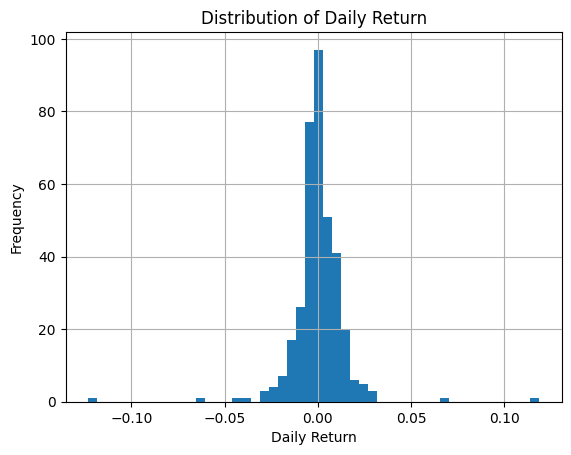

In [20]:
# Visualization 
'''If the histogram is symmetric, mean ≈ median ≈ mode.
   If right-skewed, positive returns dominate (bullish).
   If left-skewed, negative returns dominate (bearish).'''

import matplotlib.pyplot as plt
RS_Data['Daily Return'].hist(bins=50)
plt.title("Distribution of Daily Return")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()



In [49]:
# Variance and Standerd deviation 
# These measure how spread out your daily returns are.
# Higher volatility means more risk (prices fluctuate more).

variance = RS_Data['Daily Return'].var()
std_dev = RS_Data['Daily Return'].std()

print("Variance:", variance)
print("Standard Deviation:", std_dev)

Variance: 0.00020164214112615027
Standard Deviation: 0.014200075391565717


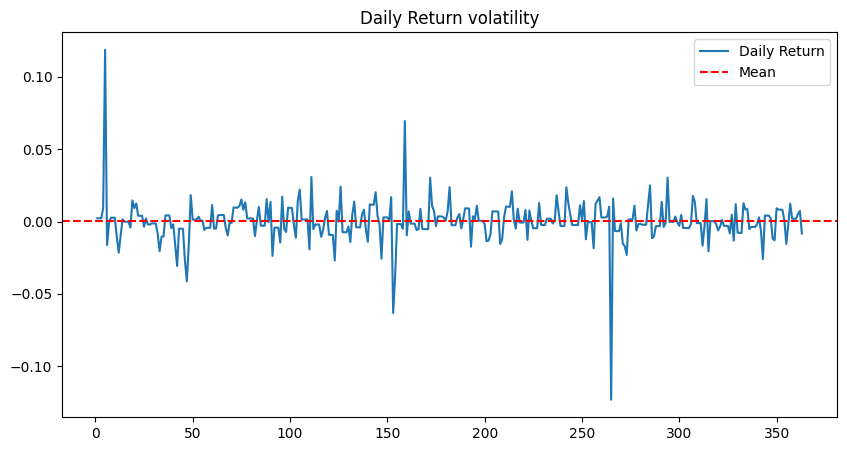

In [41]:
# Visualization 

import matplotlib.pyplot as plt

# Plot daily returns
ax = RS_Data['Daily Return'].plot(title="Daily Return volatility", figsize=(10,5))

# Draw horizontal line for mean
ax.axhline(mean_return, color="red", linestyle= "--", label="Mean")
#RS_Data.axhline(mean_return, col="red", linestyle= "--", label="Mean") - will only be used in case of Pandas DataFrame.

plt.legend()
plt.show()

In [23]:
# Skewness, Kurtosis

# Analyze the distribution of daily returns to assess skewness.

skew = RS_Data['Daily Return'].skew()
kurt = RS_Data['Daily Return'].kurt()

print("Skewness:", skew)
print("Kurtosis:", kurt)

Skewness: -0.21419782442201257
Kurtosis: 30.45550102688079


In [24]:
# Correlation → Relationship Between Features
# Shows how two numerical features move together (e.g., daily returns vs log returns).

correlation = RS_Data[['Daily Return','Log Normal']].corr()
print(correlation)

Price         Daily Return  Log Normal
Price                                 
Daily Return  1.000000      0.999183  
Log Normal    0.999183      1.000000  


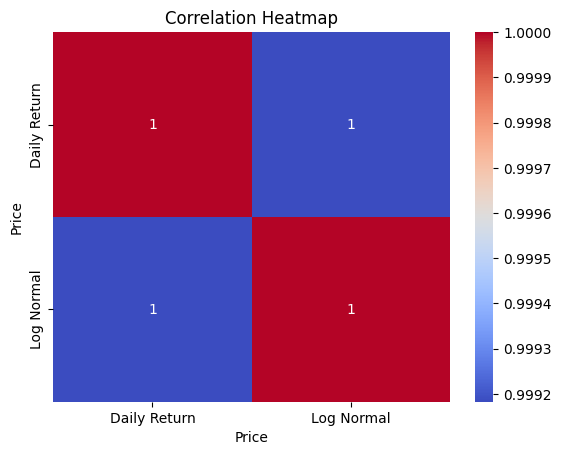

In [25]:
# Visualization 

import seaborn as sns
sns.heatmap(correlation, annot= True, cmap="coolwarm") 

#Seaborn heatmap tutorial (Python Data Visualization)Seaborn heatmaps are used to visualize rectangular data, like correlation matrices, as a color-coded matrix to identify patterns, trends, and outliers

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Covariance - Joint Variability

# It shows how two datas move together
# Positive → both rise/fall together
# Negative → move in opposite directions
# Close to zero → unrelated

covariance = RS_Data[['Daily Return','Log Normal']].cov()
print(covariance)

Price         Daily Return  Log Normal
Price                                 
Daily Return  0.000202      0.000202  
Log Normal    0.000202      0.000203  


In [27]:
# OUTLIER DETECTION → Extreme Movements

# Outliers indicate sudden market shocks (crash/surge).
# We use Z-score method to identify points beyond ±3 Standard Deviations.

mean = RS_Data.mean()
std_dev = RS_Data.std()

RS_Data['Z_Score'] = (RS_Data['Daily Return']-mean)/std_dev
outliers = RS_Data[(RS_Data['Z_Score']>3)|(RS_Data['Z_Score']<-3)]
print ("Outliers:", outliers)

Outliers: Empty DataFrame
Columns: [Date, Close, High, Low, Open, Volume, Daily Return, Log Normal, SMA_20, SMA_50, EMA_20, EMA_50, Rolling_Volatility_20, Z_Score]
Index: []


##### 6. Visualization 

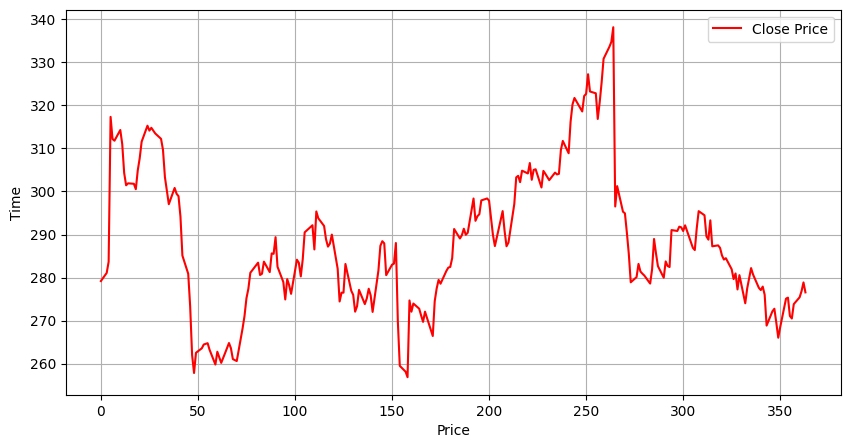

In [28]:
# Price vs Time 

plt.figure(figsize=(10,5))
plt.plot(RS_Data['Close'],color="Red", label="Close Price")
plt.xlabel("Price")
plt.ylabel("Time")
plt.legend()
plt.grid()
plt.show()



C:\Users\shree\AppData\Local\Temp\ipykernel_3340\888670681.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


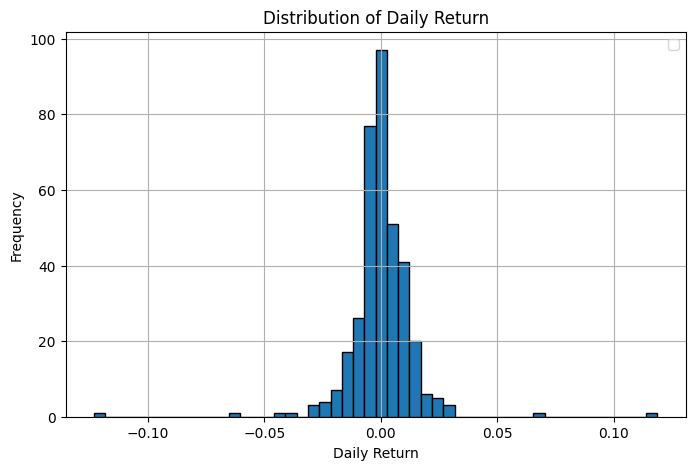

In [29]:
# Distribution of Returns

plt.figure(figsize=(8,5))
RS_Data['Daily Return'].hist(bins=50, edgecolor = 'black')
plt.title("Distribution of Daily Return")
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

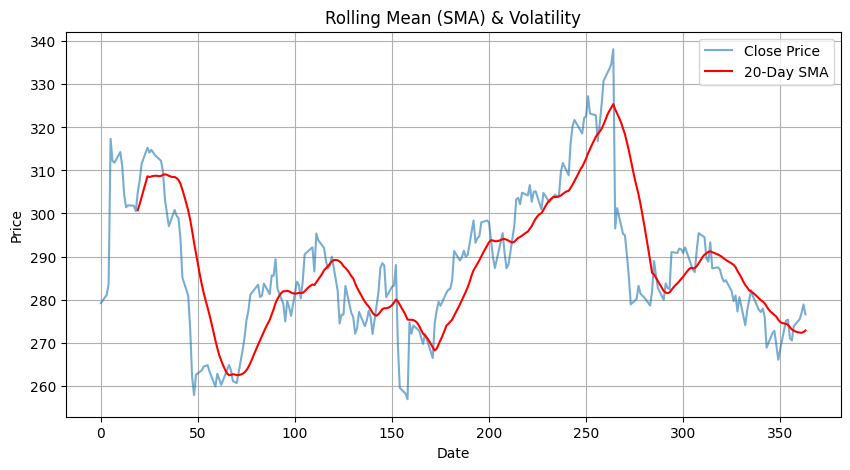

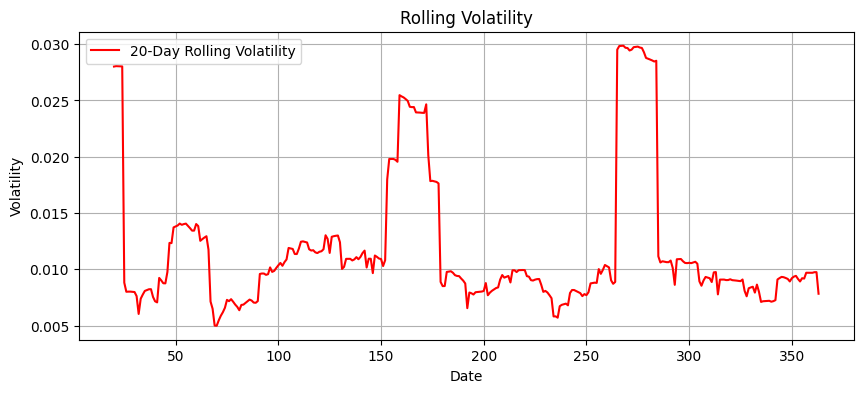

In [30]:
# Rolling Mean & Volatility
RS_Data['SMA_20'] = RS_Data['Close'].rolling (window = 20).mean()
RS_Data['Volatility_20'] = RS_Data['Daily Return'].rolling (window = 20).std()

plt.figure(figsize = (10,5))
plt.plot(RS_Data['Close'], label = 'Close Price', alpha = 0.6)
plt.plot(RS_Data['SMA_20'], label = "20-Day SMA", color = "red")
plt.title("Rolling Mean (SMA) & Volatility")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Volatility

plt.figure(figsize=(10,4))
plt.plot(RS_Data['Volatility_20'], label='20-Day Rolling Volatility', color='red')
plt.title("Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

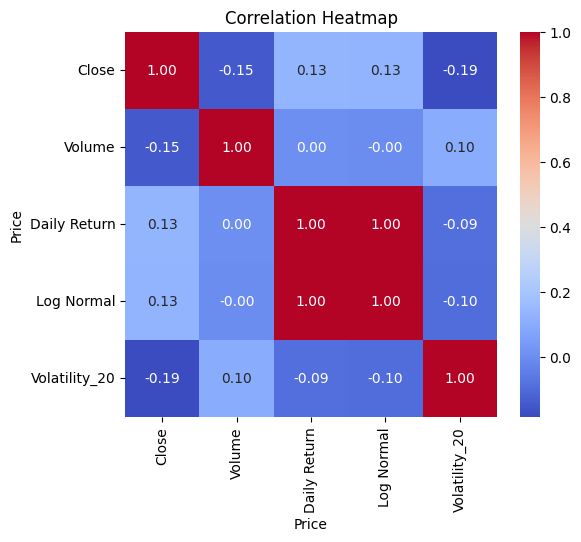

In [31]:
# Correlation Heatmap

corr = RS_Data[['Close','Volume','Daily Return','Log Normal','Volatility_20']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

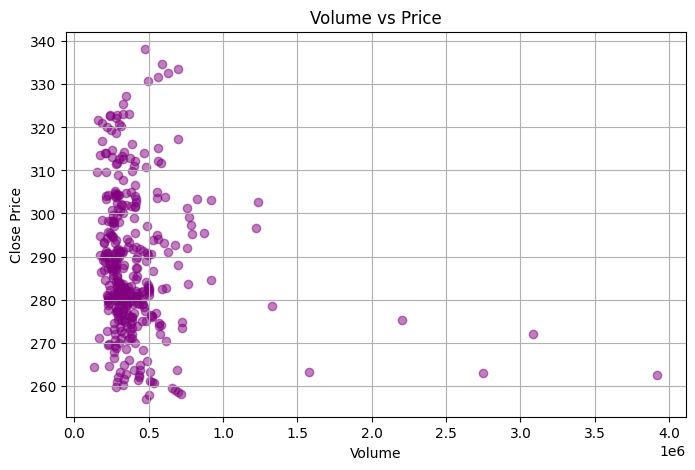

In [32]:
# Volume vs Price Relationship

plt.figure(figsize=(8,5))
plt.scatter(RS_Data['Volume'], RS_Data['Close'], alpha=0.5, color='purple')
plt.title("Volume vs Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

##### 7. Correlation & Co-Movement Analysis” (among Bitcoin, NASDAQ, S&P500, Gold, or multiple stocks)

In [ ]:
# import seaborn as sns

data = {'Bitcoin': [0.02, -0.01, 0.03, -0.005, 0.01],
        'NASDAQ': [0.015, -0.008, 0.022, -0.004, 0.007],
        'S&P500': [0.01, -0.005, 0.015, -0.006, 0.009],
        'Gold': [0.004, 0.003, -0.002, 0.001, 0.005]}

Return_df = pd.DataFrame(data)
Return_df

# Pearson Correlation

pearson_correlation = Return_df.corr(method= "pearson")
print("Pearson_Correlation:\n", pearson_correlation, "\n")

# Spearman Correlation ( Rank based, Non linear relationship)

spearman_correlation = Return_df.corr(method="spearman")
print("Spearman: \n", spearman_correlation)


Pearson_Correlation:
          Bitcoin   NASDAQ    S&P500    Gold    
Bitcoin  1.000000  0.999845  0.963779 -0.344584
NASDAQ   0.999845  1.000000  0.961445 -0.339416
S&P500   0.963779  0.961445  1.000000 -0.157383
Gold    -0.344584 -0.339416 -0.157383  1.000000 

Spearman: 
          Bitcoin  NASDAQ  S&P500  Gold
Bitcoin  1.0      1.0     0.9    -0.2 
NASDAQ   1.0      1.0     0.9    -0.2 
S&P500   0.9      0.9     1.0    -0.1 
Gold    -0.2     -0.2    -0.1     1.0 


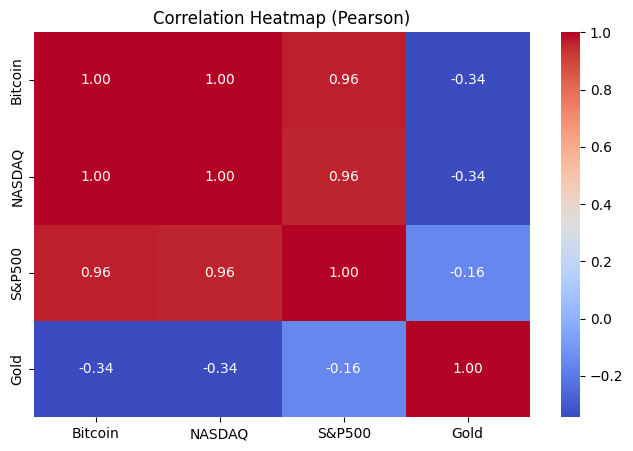

In [34]:
# Heatmap of Correlation Matrix

plt.figure(figsize=(8,5))
sns.heatmap(pearson_correlation, annot = True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Pearson)")
plt.show() 

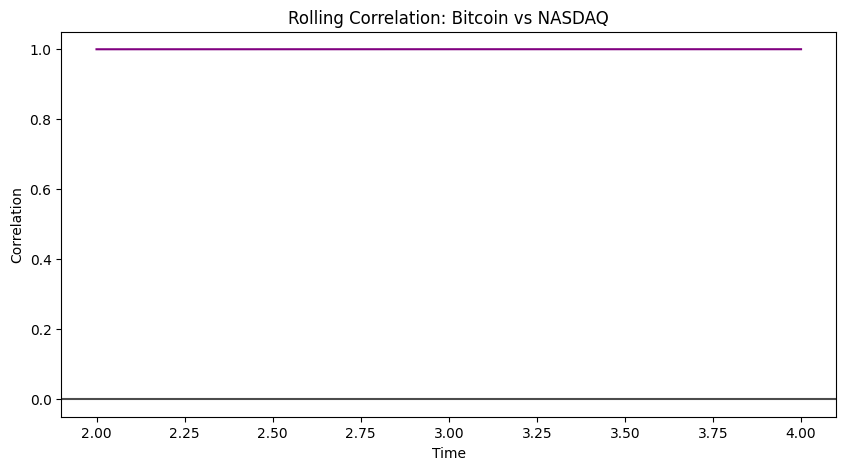

In [35]:
# Assuming you have time series data for Bitcoin & NASDAQ returns
# Example rolling correlation window = 3 days
rolling_corr = Return_df['Bitcoin'].rolling(window=3).corr(Return_df['NASDAQ'])

plt.figure(figsize=(10,5))
plt.plot(rolling_corr, color='purple')
plt.title("Rolling Correlation: Bitcoin vs NASDAQ")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.axhline(0, color='black', linestyle='-', alpha=0.7)
plt.show()


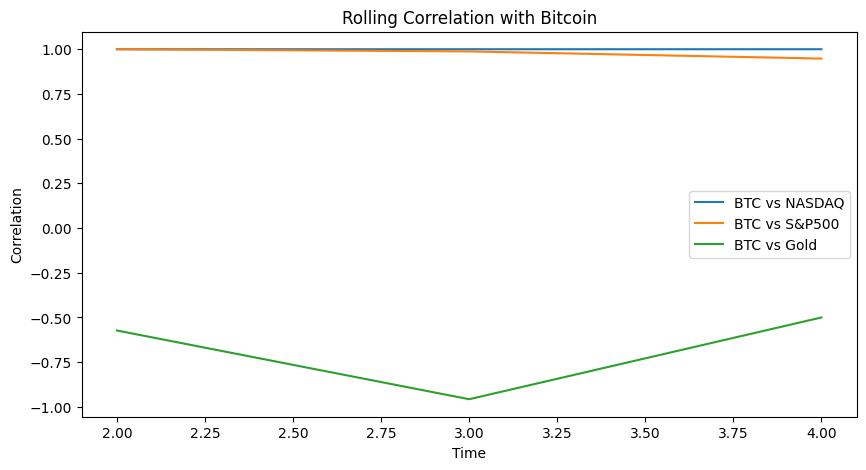

In [36]:
# Compare Bitcoin with all other assets over time

plt.figure(figsize=(10,5))
for col in ['NASDAQ', 'S&P500', 'Gold']:
    plt.plot(Return_df['Bitcoin'].rolling(3).corr(Return_df[col]), label=f'BTC vs {col}')

plt.title("Rolling Correlation with Bitcoin")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.legend()
plt.show()


##### 8. Stationarity & Distribution Checks

In [37]:
# Stationarity & Distribution Checks
# p-value < 0.05 → Stationary

from statsmodels.tsa.stattools import adfuller

# Apply ADF test on 'Daily Return'

adf_result = adfuller(RS_Data['Daily Return'].dropna())

print("adf_statistics:", adf_result[0])
print("p_value:", adf_result[1])
print("Critical_value:")
for key, value in adf_result[4].items():
    print(f" {key}: {value}")
if adf_result[1] <0.05:
    print("\n Series is stationary(Rejects Null Hypothesis)")
else:
    print("\n Series is non-stationary(Fail to Reject Null Hypothesis)")


adf_statistics: -18.26504208385405
p_value: 2.3264490447147518e-30
Critical_value:
 1%: -3.448544133483233
 5%: -2.8695574079525565
 10%: -2.5710411593052713

 Series is stationary(Rejects Null Hypothesis)


In [ ]:
# Normality test (Shapiro-Wilk/Jarque-Bera)
# p-value < 0.05 → Not normal

from scipy.stats import shapiro,jarque_bera

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = shapiro(RS_Data['Daily Return'].dropna())
print("\nShapiro-Wilk Test:")
print(f"Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
# f = formatted string literal

# Jarque-Bera Test
jb_stat,jb_p = jarque_bera(RS_Data['Daily Return'].dropna())
print("\nJarque-Bera Test:")
print(f"Statistic = {jb_stat:.4f}, p-value = {jb_p:.4f}")
# f = formatted string literal

if jb_p < .05:
    print("\nReturns are not normally distributed")
else:
    print("\nReturns are approxmately normal")


Shapiro-Wilk Test:
Statistic=0.7389, p-value=0.0000

Jarque-Bera Test:
Statistic = 13634.4396, p-value = 0.0000

Returns are not normally distributed


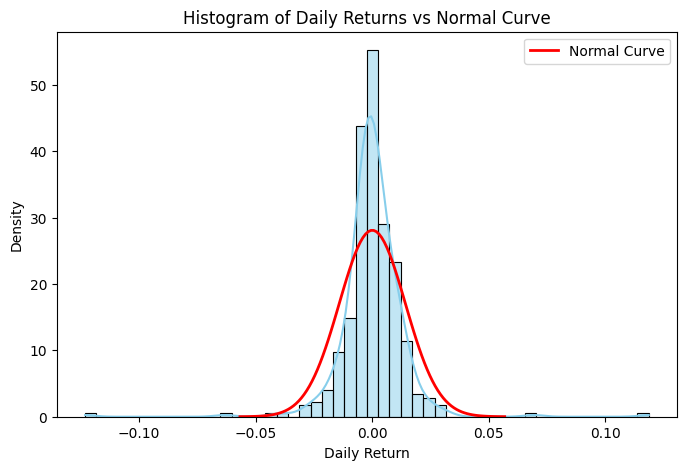

In [39]:

# Histogram vs Normal Curve Visualization

import seaborn as sns

# Plot histogram with kernel density + normal curve
plt.figure(figsize=(8,5))
sns.histplot(RS_Data['Daily Return'].dropna(), bins=50, kde=True, stat='density', color='skyblue')
# kde=True automatically calculates and draws a Kernel Density Estimate curve over your plot.

# Overlay normal curve
mean = RS_Data['Daily Return'].mean()
std = RS_Data['Daily Return'].std()
x = np.linspace(mean - 4*std, mean + 4*std, 100)
plt.plot(x, (1/(std*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2), color='red', linewidth=2, label='Normal Curve')

plt.title("Histogram of Daily Returns vs Normal Curve")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.show()


##### 9. Key Findings

- Historical stock and Bitcoin data was collected and preprocessed successfully.
- Daily returns and log returns were calculated for financial analysis.
- Rolling volatility highlighted changes in market risk over time.
- Moving Averages (SMA & EMA) identified underlying market trends.
- Correlation analysis explained relationships between financial variables.
- ADF Test was used to check stationarity.
- Shapiro-Wilk and Jarque-Bera tests were used to assess return normality.

##### 10. Conclusion

This project demonstrates a complete financial data analysis workflow using Python. It combines data preprocessing, exploratory data analysis (EDA), technical indicators, visualization, correlation analysis, and statistical testing to understand stock and Bitcoin market behavior. The project provides a strong foundation for portfolio optimization, quantitative finance, and machine learning applications in financial markets.